# 18. Evaluate pseudotime goodness-of-fit by scDesigner

This notebook gives an example of using scDesigner to evaluate psuedotime goodness-of-fit, where better pseudotime labels are expected to give better-fitted models. We will again use the scDesigner BIC information as the unsupervised metric for evaluation (see using scDesigner to evaluate clustering assignments [here](17-clustering-goodness-of-fit.ipynb)). 

The dataset we use in this example is a synthetic single-cell RNA-seq dataset with simple linear trajectory, generated using [`dyngen`](https://github.com/dynverse/dyngen) package in R. The dataset contains 500 cells and 155 genes, and its ground-truth pseudotime values are saved in the `pseudotime` column of the `anndata.obs` dataframe.

In [1]:
# from scdesigner.datasets import pseudotime_example

# example_sce = pseudotime_example()
# example_sce

import anndata as ad

example_sce = ad.read_h5ad("data/pseudotime_example.h5ad")
example_sce.obs.head()

,step_ix,simulation_i,sim_time,pseudotime
cell1,106,3,16.008333,0.263991
cell2,1169,27,44.008333,0.702819
cell3,1305,30,60.008333,0.988890
cell4,762,18,0.000000,0.027913
cell5,19,1,20.008333,0.383419


Now we create a list of 11 `anndata` objects, each with 0%, 10%, 20%, ..., 100% of the `pseudotime` variable perturbed. We will copy the original `anndata` object, replacing a specific proportion of its `pseudotime` values with numbers randomly generated from a standard uniform distribution, and save it to the `perturbed_list`. 

In [2]:
import numpy as np
import copy

np.random.seed(123)

original_pseudotime = example_sce.obs["pseudotime"].values

perturbed_list = []

for x in range(10):
    perturb_prop = x/10
    n_cell = int(round(example_sce.n_obs * perturb_prop))

    cell_index = np.random.choice(example_sce.n_obs, size=n_cell, replace=False)

    new_pseudotime = original_pseudotime.copy()
    new_pseudotime[cell_index] = np.random.uniform(0, 1, n_cell)

    new_sce = example_sce.copy()
    new_sce.obs["pseudotime"] = new_pseudotime

    perturbed_list.append(new_sce)

perturbed_list[:3]

[AnnData object with n_obs × n_vars = 500 × 155
     obs: 'step_ix', 'simulation_i', 'sim_time', 'pseudotime'
     var: 'module_id', 'basal', 'burn', 'independence', 'color', 'is_tf', 'is_hk', 'transcription_rate', 'splicing_rate', 'translation_rate', 'mrna_halflife', 'protein_halflife', 'mrna_decay_rate', 'protein_decay_rate', 'max_premrna', 'max_mrna', 'max_protein', 'mol_premrna', 'mol_mrna', 'mol_protein'
     uns: 'X_name', 'traj_dimred_segments', 'traj_milestone_network', 'traj_progressions'
     obsm: 'MDS'
     layers: 'counts_protein', 'counts_spliced', 'counts_unspliced', 'logcounts',
 AnnData object with n_obs × n_vars = 500 × 155
     obs: 'step_ix', 'simulation_i', 'sim_time', 'pseudotime'
     var: 'module_id', 'basal', 'burn', 'independence', 'color', 'is_tf', 'is_hk', 'transcription_rate', 'splicing_rate', 'translation_rate', 'mrna_halflife', 'protein_halflife', 'mrna_decay_rate', 'protein_decay_rate', 'max_premrna', 'max_mrna', 'max_protein', 'mol_premrna', 'mol_mrna',

This way we've created a list of datasets with varying degrees of wrongly-determined pseudotimes, and we will fit `NegBinCopula` models on these datasets separately. We will use the square of pearson correlation ($r^2$) between the ground truth pseudotime and perturbed pseudotime as the measurement for pseudotime quality; a higher $r^2$ indicates better quality.

We would expect the models that are fitted on less-perturbed pseudotime values (therefore better pseudotime quality) to have better performance.

In [ ]:
from scdesigner.simulators import NegBinCopula
from scipy.stats import pearsonr
import pandas as pd
import scipy

rows = []
for sce in perturbed_list:
    if scipy.sparse.issparse(sce.X):
        sce.X = sce.X.toarray()
    sim = NegBinCopula(mean_formula="~ bs(pseudotime, degree=9)")
    sim.fit(sce, batch_size=500)
    metrics = sim.complexity()

    r2 = pearsonr(sce.obs["pseudotime"].values, original_pseudotime)[0] ** 2

    rows.append(
        {
            "bic_marginal": metrics['marginal_bic'],
            "bic_copula": metrics['copula_bic'],
            "bic_total": metrics['marginal_bic'] + metrics['copula_bic'],
            "r2": r2,
        }
    )

metric = pd.DataFrame(rows)
metric

Epoch 103/500, Loss: 2.9570, Val Loss: 2.7972


Computing log-likelihood...: 100%|██████████| 1/1 [00:00<00:00,  3.75it/s]


Epoch 282/500, Loss: 3.1690, Val Loss: 3.0531


Computing log-likelihood...: 100%|██████████| 1/1 [00:00<00:00, 14.16it/s]


Epoch 10/500, Loss: 3.2864, Val Loss: 3.0403


...

Epoch 164/500, Loss: 3.4276, Val Loss: 3.2284


Computing log-likelihood...: 100%|██████████| 1/1 [00:00<00:00, 15.51it/s]


Epoch 159/500, Loss: 3.4335, Val Loss: 3.2429


Computing log-likelihood...: 100%|██████████| 1/1 [00:00<00:00, 15.12it/s]


,bic_marginal,bic_copula,bic_total,r2
0,466481.094308,31330.081566,497811.175874,1.000000
1,500022.656808,8580.437070,508603.093878,0.825579
2,516892.500558,-1777.900665,515114.599893,0.689455
3,520700.344308,-12977.765357,507722.578951,0.485844
4,521646.844308,-14742.583063,506904.261244,0.398543
5,529380.469308,-22387.350750,506993.118557,0.363069
6,533386.313058,-26595.991376,506790.321682,0.210872
7,536637.344308,-29682.954747,506954.389561,0.116363
8,538818.844308,-31567.629431,507251.214877,0.068227
9,539855.031808,-32854.004635,507001.027173,0.022576


We can see that the marginal BIC values agree with the squared pearson correlation values.

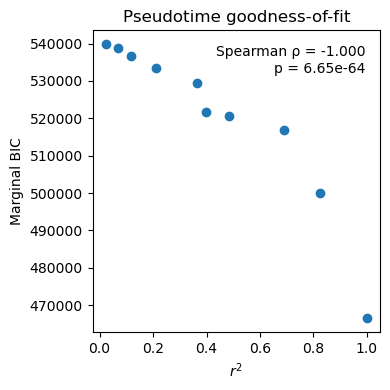

In [6]:
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

rho, pvalue = spearmanr(metric["r2"], metric["bic_marginal"])

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(metric["r2"], metric["bic_marginal"])

ax.text(
    0.95, 0.95,
    f"Spearman ρ = {rho:.3f}\np = {pvalue:.3g}",
    transform=ax.transAxes,
    ha="right", va="top",
)

ax.set_xlabel("$r^2$")
ax.set_ylabel("Marginal BIC")
ax.set_title("Pseudotime goodness-of-fit")
fig.tight_layout()
plt.show()